# MLP Baseline — Регрессия популярности банкоматов

## Описание задачи

Задача: **регрессия** — предсказание показателя популярностикаждого банкомата.  
Метрика оптимизации: **RMSE** (чем меньше — тем лучше).  

Признаки делятся на четыре группы:
- **Бинарные (17)** — наличие сервисов (cash_in, cash_out, contactless и др.)
- **Расстояния (17)** — до ближайших объектов инфраструктуры (метры)
- **Счётчики (25)** — количество объектов в радиусе 300 м
- **Экономические (4)** — средняя зарплата, ВВП на душу, плотность населения
- **Категориальные (4)** — федеральный округ и тп

Сплит: **Train 70% / Val 15% / Test 15%**.

## Архитектура модели

Полносвязная сеть (MLP) со следующей схемой:

```
Input(67) → BatchNorm → [Linear → BatchNorm → ReLU → Dropout(0.3)] × 3 → Linear → Output(1)
```

| Слой | Размерность |
|---|---|
| Entry | 67 |
| Hidden 1 | 256 |
| Hidden 2 | 128 |
| Hidden 3 | 64 |
| Exit | 1 |

- BatchNorm на входе стабилизирует масштаб признаков.  
- Dropout (p=0.3) в каждом блоке предотвращает переобучение.  
- Оптимизатор: **Adam** (lr=1e-3, weight_decay=1e-4).  
- Scheduler: **ReduceLROnPlateau** (×0.5 при отсутствии улучшений 10 эпох).  
- Early stopping: терпение 20 эпох по val RMSE.

## 0. Подключаем Google drive и настраиваем пути

In [16]:
# Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Указываем путь до датасета (загружен вручную в текущую сессию)
DATA_PATH  = Path('/content/train_data_v2.csv')

# Модель сохраняется на Google Drive
MODELS_DIR = Path('/content/drive/MyDrive')
MODELS_DIR.mkdir(exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Импорты

In [17]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42 # фиксируем seed
TEST_SIZE = 0.15  # доля тестовой выборки
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu' # Обучение на GPU

# Фиксируем генераторы случайных чисел
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f'Device: {DEVICE}', f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')

Device: cuda (Tesla T4)


## 2. Загрузка данных и предобработка

In [18]:
# Читаем датасет
df = pd.read_csv(DATA_PATH)
print(f'Датасет: {df.shape[0]} строк × {df.shape[1]} колонок')

Датасет: 6200 строк × 134 колонок


In [19]:
# Бинарные признаки
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center',
    'has_subway_nearby',
]

# Расстояния до ближайших объектов инфраструктуры (в метрах)
DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m', 'nearest_subway_dist_m',
    'nearest_post_offices_dist_m', 'nearest_offices_dist_m',
    'nearest_shops_food_small_dist_m', 'nearest_fitness_sport_dist_m',
    'nearest_hotels_hostels_dist_m', 'land_use_dist_m', 'city_center_dist_m',
    'nearest_residential_landuse_dist_m',
]

# Количество объектов в радиусе 300 м от банкомата
COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m', 'count_education_300m',
    'count_post_offices_300m', 'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m', 'count_hypermarkets_300m',
    'count_markets_300m', 'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

# Макроэкономические показатели региона
ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

# Категориальные признаки
CATEGORICAL_FEATURES = ['federal_district', 'city_size_category', 'land_use_type', 'atm_group']

# Итоговый список признаков
ALL_FEATURES = (
    BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
    ECONOMIC_FEATURES + CATEGORICAL_FEATURES
)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
CONT_COLS = [f for f in ALL_FEATURES if f not in CATEGORICAL_FEATURES]

print(f'Всего признаков: {len(ALL_FEATURES)}')

Всего признаков: 67


In [20]:
X = df[ALL_FEATURES].copy()
y = df['target'].values.reshape(-1, 1).astype(np.float32)

# Булевые столбцы приводим к int
for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

strat_col = df['city_size_category'].fillna('unknown')

# отделяем test (15%), затем из остатка val (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

# Пайплайн для непрерывных признаков
imp_cont = SimpleImputer(strategy='median')
scaler   = StandardScaler()

def process_cont(X_df, fit=False):
    vals = X_df[CONT_COLS].copy().astype(float)
    # сжимаем длинные хвосты у расстояний
    for c in DISTANCE_FEATURES:
        if c in vals.columns:
            vals[c] = np.log1p(vals[c].clip(lower=0))
    if fit:
        imp_cont.fit(vals)
        scaler.fit(imp_cont.transform(vals))
    return scaler.transform(imp_cont.transform(vals)).astype(np.float32)

# Пайплайн для категориальных признаков
enc_cat = OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float32,
)

def process_cat(X_df, fit=False):
    vals = X_df[CATEGORICAL_FEATURES].fillna('unknown').astype(str)
    if fit:
        enc_cat.fit(vals)
    encoded = enc_cat.transform(vals).astype(np.float32)
    for j in range(encoded.shape[1]):
        n_known = len(enc_cat.categories_[j])
        encoded[:, j] = np.where(encoded[:, j] < 0, float(n_known), encoded[:, j])
    return encoded

# Обучаем трансформеры
process_cont(X_train, fit=True)
process_cat(X_train, fit=True)

# конкатенируем непрерывные + категориальные признаки
X_train_np = np.hstack([process_cont(X_train), process_cat(X_train)])
X_val_np = np.hstack([process_cont(X_val), process_cat(X_val)])
X_test_np = np.hstack([process_cont(X_test), process_cat(X_test)])
X_trainval_np = np.hstack([process_cont(X_trainval), process_cat(X_trainval)])
y_trainval_np = np.vstack([y_train, y_val])

INPUT_DIM = X_train_np.shape[1]
print(f'Train: {X_train_np.shape}, Val: {X_val_np.shape}, Test: {X_test_np.shape}')

Train: (4339, 67), Val: (931, 67), Test: (930, 67)


## 3. Архитектура MLP

```
Input → BatchNorm → [Linear → BatchNorm → ReLU → Dropout] × N → Linear → Output
```

In [21]:
class MLP(nn.Module):
    """
    Полносвязная сеть с BatchNorm и Dropout
    """
    def __init__(self, input_dim: int, hidden_dims: list[int], output_dim: int = 1,dropout: float = 0.3):

        super().__init__()

        # Нормализация всхе признаков всех признаков
        layers = [nn.BatchNorm1d(input_dim)]

        # Построение скрытых блоков
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h), # линейное преобразование
                nn.BatchNorm1d(h), # нормализация
                nn.ReLU(), # добавляем нелинейность
                nn.Dropout(dropout), # регуляризация
            ]
            in_dim = h

        # Выходной слой
        layers.append(nn.Linear(in_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Конфигурация модели
HIDDEN_DIMS = [256, 128, 64] # три скрытых слоя: 256 → 128 → 64
DROPOUT = 0.3 # 30% нейронов случайно отключается при обучении

model = MLP(INPUT_DIM, HIDDEN_DIMS, output_dim=1, dropout=DROPOUT).to(DEVICE)

## 4. DataLoader

In [22]:
BATCH_SIZE = 512

def make_loader(X_np, y_np, shuffle=True):
    """
    Конвертирует numpy-массивы в DataLoader
    """
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_train_np, y_train)
val_loader = make_loader(X_val_np, y_val, shuffle=False)
test_loader = make_loader(X_test_np, y_test, shuffle=False)

In [23]:
!pip install optuna -q

## 5. Подбор гиперпараметров - Optuna

In [24]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50

def objective(trial):
    # Перебираем разное количество скрытых слоёв
    n_layers = trial.suggest_int('n_layers', 1, 4)
    hidden_dims = [
        trial.suggest_categorical(f'hidden_{i}', [64, 128, 256, 512])
        for i in range(n_layers)
    ]

    # Подбираем dropout, lr и weight_decay
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    model_trial = MLP(INPUT_DIM, hidden_dims, output_dim=1, dropout=dropout).to(DEVICE)
    opt_trial   = torch.optim.Adam(model_trial.parameters(), lr=lr, weight_decay=weight_decay)
    crit_trial  = nn.MSELoss()

    best_val = float('inf')
    no_imp   = 0

    for epoch in range(100):
        model_trial.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model_trial(X_batch)
            loss  = crit_trial(preds, y_batch)
            opt_trial.zero_grad()
            loss.backward()
            opt_trial.step()

        # Считаем val RMSE
        model_trial.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds     = model_trial(X_batch.to(DEVICE))
                val_loss += crit_trial(preds, y_batch.to(DEVICE)).item() * len(X_batch)
        val_rmse = np.sqrt(val_loss / len(val_loader.dataset))

        trial.report(val_rmse, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Early stopping внутри триала
        if val_rmse < best_val:
            best_val = val_rmse
            no_imp   = 0
        else:
            no_imp += 1
            if no_imp >= 10:
                break

    return best_val

# Запускаем подбор гиперпараметров
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=10)
study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'Лучший val RMSE по Optuna: {study.best_value:.4f}')
print(f'Лучшие параметры: {best_params}')

best_hidden_dims = [
    best_params[f'hidden_{i}'] for i in range(best_params['n_layers'])
]

  0%|          | 0/50 [00:00<?, ?it/s]

Лучший val RMSE по Optuna: 0.0479
Лучшие параметры: {'n_layers': 1, 'hidden_0': 128, 'dropout': 0.21103118844769722, 'lr': 0.007832921114568405, 'weight_decay': 0.00022200851601376982}


## 6. Обучение Baseline

In [25]:
HIDDEN_DIMS  = [256, 128, 64]
DROPOUT= 0.3
LR= 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
PATIENCE = 20

model = MLP(INPUT_DIM, HIDDEN_DIMS, output_dim=1, dropout=DROPOUT).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6,
)

def run_epoch(loader, mdl, opt, train=True):
    """
    Один проход по датасету — возвращает RMSE.
    """
    mdl.train() if train else mdl.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = mdl(X_batch)
            loss  = criterion(preds, y_batch)
            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()
            total_loss += loss.item() * len(X_batch)
    return np.sqrt(total_loss / len(loader.dataset))

history_base = {'train_rmse': [], 'val_rmse': []}
best_val_rmse_base = float('inf')
best_state_base = None
no_improve = 0

t0 = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    tr_rmse  = run_epoch(train_loader, model, optimizer, train=True)
    val_rmse = run_epoch(val_loader, model, optimizer, train=False)
    scheduler.step(val_rmse)

    history_base['train_rmse'].append(tr_rmse)
    history_base['val_rmse'].append(val_rmse)

    if val_rmse < best_val_rmse_base:
        best_val_rmse_base = val_rmse
        best_state_base = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping: эпоха {epoch}')
            break

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Эпоха {epoch:3d}, train RMSE={tr_rmse:.4f}, val RMSE={val_rmse:.4f}, lr={lr_now:.2e}')

fit_time_base = time.perf_counter() - t0
model.load_state_dict(best_state_base)
print(f'\nВремя обучения (baseline): {fit_time_base:.1f} с')
print(f'Лучший val RMSE (baseline): {best_val_rmse_base:.4f}')

Эпоха   1, train RMSE=0.4450, val RMSE=0.0911, lr=1.00e-03
Эпоха   2, train RMSE=0.3172, val RMSE=0.1029, lr=1.00e-03
Эпоха   3, train RMSE=0.2843, val RMSE=0.0998, lr=1.00e-03
Эпоха   4, train RMSE=0.2541, val RMSE=0.1098, lr=1.00e-03
Эпоха   5, train RMSE=0.2303, val RMSE=0.0917, lr=1.00e-03
Эпоха   6, train RMSE=0.2096, val RMSE=0.0838, lr=1.00e-03
Эпоха   7, train RMSE=0.1857, val RMSE=0.0828, lr=1.00e-03
Эпоха   8, train RMSE=0.1702, val RMSE=0.0785, lr=1.00e-03
Эпоха   9, train RMSE=0.1579, val RMSE=0.0737, lr=1.00e-03
Эпоха  10, train RMSE=0.1473, val RMSE=0.0728, lr=1.00e-03
Эпоха  11, train RMSE=0.1411, val RMSE=0.0729, lr=1.00e-03
Эпоха  12, train RMSE=0.1317, val RMSE=0.0719, lr=1.00e-03
Эпоха  13, train RMSE=0.1252, val RMSE=0.0710, lr=1.00e-03
Эпоха  14, train RMSE=0.1217, val RMSE=0.0695, lr=1.00e-03
Эпоха  15, train RMSE=0.1177, val RMSE=0.0693, lr=1.00e-03
Эпоха  16, train RMSE=0.1130, val RMSE=0.0688, lr=1.00e-03
Эпоха  17, train RMSE=0.1112, val RMSE=0.0679, lr=1.00e-

## 7. Обучение модели с параметрами от Optuna

In [26]:
model_opt = MLP(
    INPUT_DIM,
    best_hidden_dims,
    output_dim=1,
    dropout=best_params['dropout']
).to(DEVICE)

optimizer_opt = torch.optim.Adam(
    model_opt.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)
scheduler_opt = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_opt, mode='min', factor=0.5, patience=10, min_lr=1e-6,
)

history_opt = {'train_rmse': [], 'val_rmse': []}
best_val_rmse_opt  = float('inf')
best_state_opt = None
no_improve_opt = 0

t0 = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    tr_rmse  = run_epoch(train_loader, model_opt, optimizer_opt, train=True)
    val_rmse = run_epoch(val_loader,   model_opt, optimizer_opt, train=False)
    scheduler_opt.step(val_rmse)

    history_opt['train_rmse'].append(tr_rmse)
    history_opt['val_rmse'].append(val_rmse)

    if val_rmse < best_val_rmse_opt:
        best_val_rmse_opt = val_rmse
        best_state_opt = {k: v.cpu().clone() for k, v in model_opt.state_dict().items()}
        no_improve_opt = 0
    else:
        no_improve_opt += 1
        if no_improve_opt >= PATIENCE:
            print(f'Early stopping: эпоха {epoch}')
            break

    lr_now = optimizer_opt.param_groups[0]['lr']
    print(f'Эпоха {epoch:3d}, train RMSE={tr_rmse:.4f}, val RMSE={val_rmse:.4f}, lr={lr_now:.2e}')

fit_time_opt = time.perf_counter() - t0
model_opt.load_state_dict(best_state_opt)
print(f'\nВремя обучения (Optuna): {fit_time_opt:.1f} с')
print(f'Лучший val RMSE (Optuna): {best_val_rmse_opt:.4f}')

Эпоха   1, train RMSE=0.3319, val RMSE=0.1480, lr=7.83e-03
Эпоха   2, train RMSE=0.1573, val RMSE=0.0951, lr=7.83e-03
Эпоха   3, train RMSE=0.0985, val RMSE=0.0725, lr=7.83e-03
Эпоха   4, train RMSE=0.0779, val RMSE=0.0670, lr=7.83e-03
Эпоха   5, train RMSE=0.0698, val RMSE=0.0625, lr=7.83e-03
Эпоха   6, train RMSE=0.0641, val RMSE=0.0608, lr=7.83e-03
Эпоха   7, train RMSE=0.0633, val RMSE=0.0584, lr=7.83e-03
Эпоха   8, train RMSE=0.0607, val RMSE=0.0586, lr=7.83e-03
Эпоха   9, train RMSE=0.0590, val RMSE=0.0574, lr=7.83e-03
Эпоха  10, train RMSE=0.0582, val RMSE=0.0562, lr=7.83e-03
Эпоха  11, train RMSE=0.0565, val RMSE=0.0553, lr=7.83e-03
Эпоха  12, train RMSE=0.0551, val RMSE=0.0562, lr=7.83e-03
Эпоха  13, train RMSE=0.0562, val RMSE=0.0558, lr=7.83e-03
Эпоха  14, train RMSE=0.0547, val RMSE=0.0550, lr=7.83e-03
Эпоха  15, train RMSE=0.0537, val RMSE=0.0542, lr=7.83e-03
Эпоха  16, train RMSE=0.0528, val RMSE=0.0529, lr=7.83e-03
Эпоха  17, train RMSE=0.0528, val RMSE=0.0525, lr=7.83e-

## 8. Кривые обучения — Baseline vs Optuna

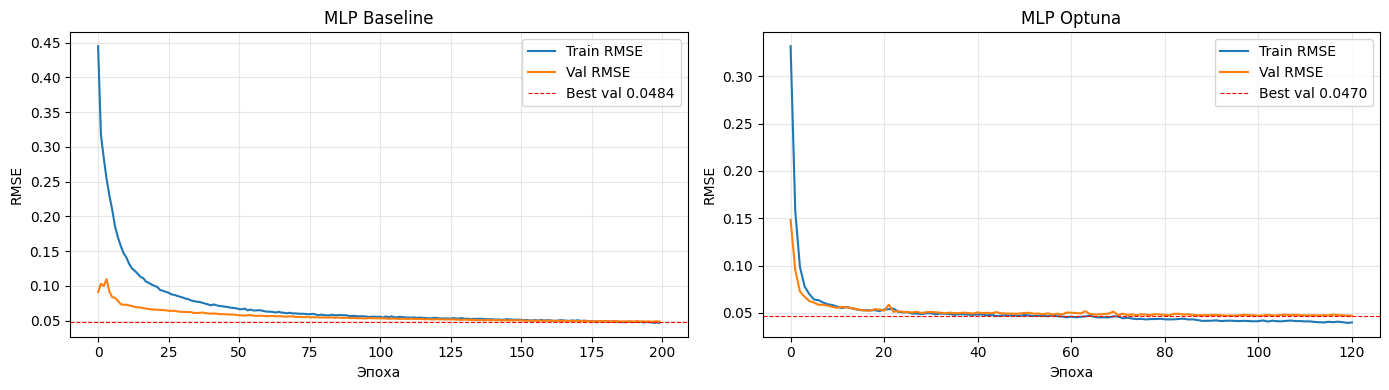

In [27]:
# Сравниваем динамику обучения двух моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, history, label, best in [
    (axes[0], history_base, 'Baseline', best_val_rmse_base),
    (axes[1], history_opt,  'Optuna',   best_val_rmse_opt),
]:
    ax.plot(history['train_rmse'], label='Train RMSE')
    ax.plot(history['val_rmse'],   label='Val RMSE')
    ax.axhline(best, color='red', ls='--', lw=0.8, label=f'Best val {best:.4f}')
    ax.set_title(f'MLP {label}')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('RMSE')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Сравнение метрик: Baseline vs Optuna

In [28]:
def predict_np(mdl, loader):
    """
    Возвращает предсказания в numpy
    """
    mdl.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            preds.append(mdl(X_batch.to(DEVICE)).cpu().numpy())
    return np.concatenate(preds).flatten()

def metrics(y_true, y_pred):
    """
    Возвращает словарь с RMSE, MAE, R²
    """
    return {
        'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'MAE': round(float(mean_absolute_error(y_true, y_pred)), 4),
        'R²': round(float(r2_score(y_true, y_pred)), 4),
    }

# Предсказания моделей на test
y_pred_base = predict_np(model, test_loader)
y_pred_opt  = predict_np(model_opt, test_loader)
y_test_flat = y_test.flatten()

# Собираем итоговую таблицу результатов
res = pd.DataFrame([
    {'Модель': 'MLP Baseline', **metrics(y_test_flat, y_pred_base)},
    {'Модель': 'MLP + Optuna', **metrics(y_test_flat, y_pred_opt)},
]).set_index('Модель')

display(
    res.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}', 'Fit time, s': '{:.1f}'})
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R²'])
)

,RMSE,MAE,R²
Модель,,,
MLP Baseline,0.0522,0.0414,0.6343
MLP + Optuna,0.0493,0.0395,0.6736


## 10. Сохранение лучшей модели

In [29]:
# Сохраняем обе модели на Google Drive
for name, mdl, hd, dp, val_rmse in [
    ('mlp_baseline.pt', model, HIDDEN_DIMS, DROPOUT, best_val_rmse_base),
    ('mlp_optuna.pt',   model_opt, best_hidden_dims, best_params['dropout'],  best_val_rmse_opt),
]:
    torch.save({
        'model_state_dict': mdl.state_dict(),
        'hidden_dims': hd,
        'dropout': dp,
        'input_dim': INPUT_DIM,
        'val_rmse': val_rmse,
    }, MODELS_DIR / name)
    print(f'Сохранено: {MODELS_DIR / name}')

Сохранено: /content/drive/MyDrive/mlp_baseline.pt
Сохранено: /content/drive/MyDrive/mlp_optuna.pt


## 11. Выводы

### Результаты обучения

**Baseline** обучался все 200 эпох (early stopping не сработал), лучший val RMSE = **0.0484**.
**Optuna** остановился на эпохе 121 (early stopping сработал), лучший val RMSE = **0.0470**.

### Baseline vs Optuna на тестовой выборке

| Модель | RMSE | MAE | R² |
|--------|------|-----|----|
| MLP Baseline | 0.0522 | 0.0414 | 0.6343 |
| **MLP + Optuna** | **0.0493** | **0.0395** | **0.6736** |

Optuna улучшила все три метрики:
- RMSE снизился с 0.0522 до 0.0493
- R² вырос с 0.634 до 0.674